# EDA — Polymarket wash trading (บทบาท C)

**เป้าหมาย:** สำรวจข้อมูลการเทรดบน Polymarket สองสัปดาห์ที่เปเปอร์ (Sirolly et al., 2025) บอกว่าต่างกันสุดขั้ว
- **1–7 ธ.ค. 2024 = ช่วงพีค** (เปเปอร์: wash ≈ 60% ของ volume)
- **1–7 มิ.ย. 2025 = ช่วงเงียบ** (เปเปอร์: wash < 5%)

แล้วใช้สิ่งที่เจอ (1) ทำสไลด์ Exploration และ (2) **ส่งปัญหาข้อมูล / สัญญาณที่น่าสงสัยกลับไปให้ A (data pipeline) และ B (อัลกอริทึม)**

**ที่มาของข้อมูล:** ตารางเทรดและผลที่ใช้ตรวจความถูกต้องมาจาก **premise test** (`04_Evaluation/premise_test/`)
ซึ่งทำไว้ตอนวางแผนโปรเจกต์ (30 ก.ย.) ก่อนแบ่งบทบาท — EDA นี้เป็นงานแรกหลังแบ่งบทบาท ส่วนงานของ A และ B (phase 2) ยังไม่เริ่ม
ข้อเสนอที่ "ส่งถึง A / B" ในเล่มนี้จึงเป็น **ข้อมูลตั้งต้นสำหรับงานของเขา** ไม่ใช่การตรวจงานที่เขาทำแล้ว

**ทำไมต้องเทียบสองช่วง:** EDA ของเราไม่มี "ป้ายเฉลย" ว่าเทรดไหนเป็น wash — แต่ถ้าลักษณะไหน
*ต่างกันมาก* ระหว่างช่วงที่มี wash 60% กับช่วงที่มี < 5% ลักษณะนั้นก็น่าจะเป็นร่องรอยของ wash
(ใช้ช่วงเงียบเป็น "กลุ่มควบคุม")

| # | หัวข้อ | คำถามหลัก | ส่งถึง |
|---|---|---|---|
| 1 | ภาพรวม | ข้อมูลใหญ่แค่ไหน และตรงกับผล premise test ไหม | สไลด์ |
| 2 | volume รายวัน | สัปดาห์ที่เลือกผิดปกติไหม มีเหตุการณ์ใหญ่ซ้อนไหม | A, B |
| 3 | degree ของกระเป๋า | กระเป๋าเทรดกับคนหลากหลาย หรือวนกับคู่เดิม | B |
| 4 | หมวดตลาด | volume กระจุกในหมวดไหน | สไลด์, B |
| 5 | ราคาและขนาดเทรด | wash ชอบตลาดราคาต่ำจริงไหม มีขนาดเทรดที่เป็นบอทไหม | B |
| 6 | อายุตลาดเทียบหน้าต่างเวลา | lead-in 1 เดือนพอไหม ต้องย้อนไปไกลแค่ไหน | **A** |
| 7 | สรุป | ข้อค้นพบทั้งหมดในตารางเดียว | ทุกคน |

**หลักที่ใช้ทุกหัวข้อ:**
1. ทำ aggregate **ใน DuckDB** ให้ได้ตารางเล็ก ๆ ก่อนดึงเข้า pandas — ตารางเทรดมีหลายล้านแถว (ช่วง ธ.ค. รวม lead-in ≈ 9.3 ล้าน)
   ถ้า `SELECT *` เข้า pandas จะกิน RAM หลาย GB และช้า
2. วาดสองหน้าต่างคู่กันด้วยสีประจำ (**ฟ้า = ธ.ค. พีค, เขียว = มิ.ย. เงียบ**) ให้ตรงกับเอกสารแผนงาน
3. ตัวเลขทุกตัวที่จะอ้างในสไลด์/รายงานผ่าน `record_stat()` → `eda_stats.json` (แหล่งเดียวของตัวเลข ไม่ต้องลอกด้วยมือ)

**วิธีรัน:** เปิดใน VS Code แล้วเลือก kernel จาก `Project/.venv` หรือจากโฟลเดอร์ `Project/`
```bash
uv run jupyter nbconvert --to notebook --execute --inplace 03_Analytics/eda/eda_round1.ipynb
```
ใช้เวลารันทั้งเล่มไม่ถึง 1 นาที (DuckDB อ่าน parquet แบบหลายเธรด)

## 0. ตั้งค่า

### 0.1 import, path และการเชื่อมต่อ DuckDB

**ทำอะไร:**
- หาโฟลเดอร์ `Project/` โดยเดินขึ้นไปจนเจอ `pyproject.toml` → notebook รันได้ไม่ว่า working directory จะอยู่ที่ไหน
- import `INTERIM`, `RAW`, `WINDOWS` จาก `04_Evaluation/premise_test/config.py` (ไฟล์ตั้งค่าของ premise test) **แทนการเขียนวันที่ซ้ำ**
  ถ้าในอนาคตมีการเปลี่ยนหน้าต่างเวลาใน `config.py` notebook นี้จะตามไปเองโดยไม่ต้องแก้
- เปิด DuckDB แบบ in-memory แล้ว **ตั้ง timezone เป็น UTC** — คอลัมน์ `ts` เป็น `TIMESTAMPTZ`
  ถ้าไม่ตั้ง `date_trunc('day', ts)` จะใช้เวลาเครื่อง (กรุงเทพ +7 ชม.) ทำให้ "วัน" เลื่อนไม่ตรงกับสัปดาห์ UTC ของเปเปอร์
- ฟังก์ชันช่วย `q()` รัน SQL แล้วคืน DataFrame และ `trades(w)` คืน path ของตารางเทรดของหน้าต่าง `w`

In [1]:
import json
import sys
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project/ = two levels up from this notebook (03_Analytics/eda/)
PROJECT = Path.cwd().resolve()
while not (PROJECT / "pyproject.toml").exists():
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT / "04_Evaluation" / "premise_test"))
from config import INTERIM, RAW, WINDOWS  # noqa: E402

HERE = PROJECT / "03_Analytics" / "eda"
FIG = HERE / "figures"
FIG.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
# ts is TIMESTAMPTZ. Without this, date_trunc('day', ts) uses the laptop's timezone
# (Asia/Bangkok, +7h) and every "day" would be shifted against the paper's UTC weeks.
con.execute("SET TimeZone = 'UTC'")


def q(sql: str) -> pd.DataFrame:
    # Run SQL in DuckDB and return a (small!) DataFrame
    return con.sql(sql).df()


def trades(w: str) -> str:
    # Path of the clean trade table for one window, ready to paste into FROM '...'
    return str(INTERIM / f"{w}_trades.parquet")


MARKETS = str(RAW / "market_data.parquet")
pd.set_option("display.max_colwidth", 70)
print("windows:", list(WINDOWS))

windows: ['dec2024', 'jun2025']


ได้หน้าต่างเวลาสองช่วงตามที่ตั้งไว้ใน `config.py` คือ `dec2024` และ `jun2025` แต่ละช่วงประกอบด้วย
**lead-in 1 เดือน** (ใช้แค่เรียนรู้ position ของกระเป๋า) + **สัปดาห์เป้าหมาย** (สัปดาห์ที่รายงานผล)

### 0.2 สี สไตล์กราฟ และตัวเก็บตัวเลข

**ทำอะไร:**
- กำหนดสีชุดเดียวกับ `plan/make_figures.py` (palette แบบ Okabe–Ito ที่คนตาบอดสีแยกได้) ให้ "ฟ้า = ช่วงพีค" ตรงกันทุกเอกสาร
- ตั้ง `rcParams` ครั้งเดียว ทุกกราฟจะหน้าตาเหมือนกันโดยไม่ต้องตั้งซ้ำ
- `save_fig()` เซฟรูปลง `figures/<ชื่อ>.png` (ตั้งชื่อนำหน้าด้วยเลขหัวข้อ เช่น `03a_...` ให้หาง่ายตอนทำสไลด์)
- `record_stat()` เก็บตัวเลขลง dict `STATS` และแปลง numpy/float ที่เป็นจำนวนเต็มให้เป็น `int` ก่อนเขียน JSON

In [2]:
# Same hues as plan/make_figures.py and the plan PDF, so "blue = peak week" holds everywhere
C_DATA, C_ALG, C_EVAL, C_EXT = "#0072B2", "#D55E00", "#009E73", "#7B5EA7"
C_INK, C_MUTED = "#1A2733", "#5B6B7A"

WIN = {
    "dec2024": {"label": "Dec 2024 (peak)", "color": C_DATA},
    "jun2025": {"label": "Jun 2025 (quiet)", "color": C_EVAL},
}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": C_MUTED, "axes.labelcolor": C_INK, "text.color": C_INK,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

STATS: dict = {w: {} for w in WIN}


def save_fig(fig, name: str) -> None:
    # Every figure goes to figures/<name>.png so the slides can pick it up
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")


def record_stat(w: str, key: str, value) -> None:
    # Every number we may quote in the slides goes through here -> eda_stats.json
    value = value.item() if hasattr(value, "item") else value
    # counts come back as floats when pandas mixes column types in one row
    if isinstance(value, float) and value.is_integer():
        value = int(value)
    STATS[w][key] = value

### 0.3 ข้อมูลที่ใช้มีคอลัมน์อะไรบ้าง

**ทำอะไร:** ดู schema ของตารางเทรดที่ได้จากขั้น extract ของ premise test (`data/interim/<window>_trades.parquet`) และตาราง `market_data`
เพื่อให้รู้ว่าแต่ละคอลัมน์หมายถึงอะไรก่อนเริ่มวิเคราะห์ — `DESCRIBE` อ่านแค่ metadata ของ parquet จึงเร็วมาก

ตารางเทรด **หนึ่งแถว = หนึ่งการจับคู่ (maker fill)** ระหว่างกระเป๋าสองใบในตลาดหนึ่ง
(แถวสรุปฝั่ง taker ที่ซ้ำกันถูกตัดทิ้งไปแล้วตอน extract โดย `01_extract.py`)

In [3]:
schema = q(f"DESCRIBE SELECT * FROM '{trades('dec2024')}'")[["column_name", "column_type"]]
schema["meaning"] = [
    "Polygon block number",
    "event index inside the block (block, log_index) = unique order",
    "trade time (UTC)",
    "True = target week, False = lead-in month",
    "market id (= condition id in market_data)",
    "wallet whose resting order was filled",
    "wallet that sent the matching order",
    "number of outcome shares traded (our volume unit)",
    "USDC paid for those shares -> price = usdc / shares",
    "change in maker position (+ buy / - sell); taker gets the opposite",
]
schema

,column_name,column_type,meaning
0,block,BIGINT,Polygon block number
1,log_index,INTEGER,"event index inside the block (block, log_index) = unique order"
2,ts,TIMESTAMP WITH TIME ZONE,trade time (UTC)
3,in_target,BOOLEAN,"True = target week, False = lead-in month"
4,market,VARCHAR,market id (= condition id in market_data)
5,maker,VARCHAR,wallet whose resting order was filled
6,taker,VARCHAR,wallet that sent the matching order
7,shares,DOUBLE,number of outcome shares traded (our volume unit)
8,usdc,DOUBLE,USDC paid for those shares -> price = usdc / shares
9,dp_maker,DOUBLE,change in maker position (+ buy / - sell); taker gets the opposite


**อ่านผล:**

- คอลัมน์ที่ใช้จริงใน EDA นี้: `ts`, `in_target` (แยก lead-in/สัปดาห์เป้าหมาย), `market`, `maker`, `taker` (สร้างกราฟกระเป๋า),
  `shares` (volume), `usdc` (คำนวณราคา)
- `dp_maker` เป็นคอลัมน์ที่ Algorithm 1 ใช้ติดตาม position — EDA ไม่ต้องใช้
- ไม่มีคอลัมน์หมวดตลาดหรือวันเปิดตลาดในตารางเทรด → ต้อง join กับ `market_data` (หัวข้อ 4 และ 6)

## 1. ภาพรวม: ข้อมูลใหญ่แค่ไหน

**คำถาม:** สัปดาห์เป้าหมายแต่ละช่วงมีกี่เทรด กี่กระเป๋า กี่ตลาด volume เท่าไร
→ ใช้ตอบสไลด์ "Complex Data" (ข้อมูลใหญ่ + เป็นกราฟ) และใช้เป็นตัวตรวจว่าข้อมูลถูก

**วิธีคิด:**
- นับเฉพาะ `in_target` (สัปดาห์เป้าหมาย) เพราะเป็นช่วงที่อัลกอริทึมรายงานผล
- **กระเป๋าต้องนับทั้งสองฝั่ง** — ใช้ `UNION` ของ `maker` กับ `taker` (`UNION` ตัดตัวซ้ำให้)
  ถ้านับแค่ `maker` กระเป๋าที่เป็น taker อย่างเดียวจะหายไป
- **share volume** = ผลรวม `shares` (หน่วยเดียวกับเปเปอร์) · **USDC volume** = เงินที่จ่ายจริง
- `usdc_per_share` = ราคาเฉลี่ยถ่วง volume ของ token ที่ถูกเทรด (อยู่ระหว่าง 0–1 เพราะ token จ่าย 1 USDC ถ้าทายถูก)

In [4]:
rows = []
for w in WIN:
    t = trades(w)
    r = q(f"""
        SELECT
            count(*)                         AS trades,
            (SELECT count(*) FROM (
                SELECT maker FROM '{t}' WHERE in_target
                UNION                                  -- UNION removes duplicates
                SELECT taker FROM '{t}' WHERE in_target)) AS wallets,
            count(DISTINCT market)           AS markets,
            sum(shares) / 1e6                AS share_volume_M,
            sum(usdc) / 1e6                  AS usdc_volume_M,
            median(shares)                   AS median_trade_shares
        FROM '{t}'
        WHERE in_target
    """).iloc[0]
    for k, v in r.items():
        record_stat(w, k, v)
    rows.append(r.rename(WIN[w]["label"]))

overview = pd.DataFrame(rows)
overview["usdc_per_share"] = overview["usdc_volume_M"] / overview["share_volume_M"]
for w, lab in zip(WIN, overview.index):
    record_stat(w, "usdc_per_share", overview.loc[lab, "usdc_per_share"])
overview.round(2)

,trades,wallets,markets,share_volume_M,usdc_volume_M,median_trade_shares,usdc_per_share
Dec 2024 (peak),1635178.0,104186.0,2307.0,692.88,182.68,46.00,0.26
Jun 2025 (quiet),1147205.0,87130.0,3918.0,389.84,169.30,36.91,0.43


**ตรวจความถูกต้อง (sanity check):** ตัวเลขจำนวนเทรด / ตลาด / volume ต้องตรงกับที่ pipeline ของ premise test รายงานไว้ใน
`04_Evaluation/premise_test/results/extract_stats.json` — ถ้าไม่ตรง แปลว่าเราอ่านข้อมูลคนละชุดหรือกรองต่างกัน
และตัวเลขที่จะอ้างในสไลด์จะขัดกับผล premise test ใช้ `assert` เพื่อให้ notebook **หยุดทันที** ถ้าไม่ตรง

In [5]:
# Sanity check against what the premise-test pipeline reported
ext = {s["window"]: s for s in json.loads(
    (PROJECT / "04_Evaluation/premise_test/results/extract_stats.json").read_text())}
for w in WIN:
    assert STATS[w]["trades"] == ext[w]["target_trades"], w
    assert STATS[w]["markets"] == ext[w]["target_markets"], w
    assert abs(STATS[w]["share_volume_M"] * 1e6 - ext[w]["target_share_volume"]) < 1, w
print("overview matches extract_stats.json ✓")

overview matches extract_stats.json ✓


**อ่านผล:**

- ข้อมูล**ตรงกับผลของ pipeline premise test** ทุกตัว (assert ผ่าน) → ตัวเลขใน EDA ใช้คู่กับผล premise test ได้
- ขนาด: สัปดาห์เดียวมี **1.6 ล้านเทรด / 1 แสนกระเป๋า** (ธ.ค.) — พอสำหรับสไลด์ "Complex Data" (big + graph)
- **USDC ต่อหุ้นเฉลี่ยแค่ 0.26 ในช่วงพีค** เทียบ 0.43 ในช่วงเงียบ → เทรดช่วงพีคอยู่ที่ราคาต่ำ
  ซึ่งตรงกับสิ่งที่เปเปอร์บอกว่า wash ชอบตลาด "โอกาสน้อย" เพราะปั่น share volume ได้ด้วยเงินน้อย (ตามต่อในหัวข้อ 5)
- ธ.ค. มีตลาด**น้อยกว่า** มิ.ย. (2,307 vs 3,918) แต่ share volume **มากกว่าเกือบเท่าตัว** (693 M vs 390 M)
  ทั้งที่ USDC volume ใกล้กัน (183 M vs 169 M) → ส่วนต่างของ volume มาจาก**หุ้นราคาถูก**ไม่ใช่เงินจริงที่มากขึ้น

## 2. volume รายวัน: ช่วงพีคกับช่วงเงียบต่างกันแค่ไหน

**คำถาม:** volume และจำนวนเทรดรายวันตลอดหน้าต่าง (lead-in 1 เดือน + สัปดาห์เป้าหมาย) หน้าตาเป็นอย่างไร
มีวันไหนกระโดดผิดปกติไหม (เช่นช่วงเลือกตั้งสหรัฐ 5–6 พ.ย. 2024)

**ทำไมสำคัญ:** ถ้าสัปดาห์เป้าหมายเองเป็นสัปดาห์ผิดปกติ (เช่นมีเหตุการณ์ใหญ่) ผล % wash อาจสะท้อนเหตุการณ์นั้นแทน
และถ้ามีเหตุการณ์ใหญ่ใน lead-in ก็จะกระทบ position ที่อัลกอริทึมเรียนรู้

**วิธี:** `date_trunc('day', ts)` แล้ว group รายวันใน DuckDB → ได้ ~38 แถวต่อหน้าต่าง
วาด 2×2 (แถว = volume / จำนวนเทรด, คอลัมน์ = หน้าต่าง) พื้นที่แรเงา = สัปดาห์เป้าหมาย

dec2024: busiest day 2024-11-06 = 531.7 M shares
jun2025: busiest day 2025-06-03 = 134.6 M shares


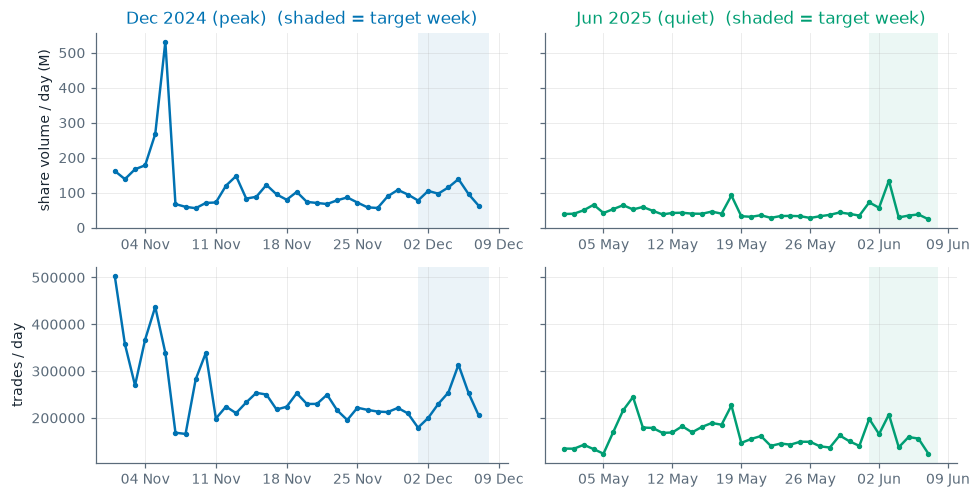

In [6]:
daily = {}
for w in WIN:
    daily[w] = q(f"""
        SELECT date_trunc('day', ts) AS day,
               count(*)              AS trades,
               sum(shares) / 1e6     AS share_volume_M,
               bool_or(in_target)    AS in_target
        FROM '{trades(w)}'
        GROUP BY 1
        ORDER BY 1
    """)

fig, axes = plt.subplots(2, 2, figsize=(9, 4.6), sharey="row")
for col, w in enumerate(WIN):
    d, c = daily[w], WIN[w]["color"]
    t0 = d.loc[d["in_target"], "day"].min()
    for row, (y, ylab) in enumerate([("share_volume_M", "share volume / day (M)"),
                                     ("trades", "trades / day")]):
        ax = axes[row, col]
        ax.plot(d["day"], d[y], color=c, lw=1.6, marker="o", ms=2.5)
        ax.axvspan(t0, d["day"].max() + pd.Timedelta(days=1), color=c, alpha=0.08, lw=0)
        if col == 0:
            ax.set_ylabel(ylab)
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    axes[0, col].set_title(WIN[w]["label"] + "  (shaded = target week)", color=c)
save_fig(fig, "02_daily_volume")

for w in WIN:
    d = daily[w]
    tgt, lead = d[d["in_target"]], d[~d["in_target"]]
    record_stat(w, "daily_volume_M_target_mean", tgt["share_volume_M"].mean())
    record_stat(w, "daily_volume_M_leadin_mean", lead["share_volume_M"].mean())
    top = d.nlargest(1, "share_volume_M").iloc[0]
    print(f"{w}: busiest day {top['day']:%Y-%m-%d} = {top['share_volume_M']:.1f} M shares")

**อ่านผล:**

- **6 พ.ย. 2024 (UTC) = คืนประกาศผลเลือกตั้งสหรัฐ** volume 532 M หุ้นในวันเดียว (~5 เท่าของวันปกติ) อยู่ใน lead-in ของหน้าต่าง ธ.ค.
- ธ.ค.: สัปดาห์เป้าหมายเฉลี่ย ~99 M/วัน **ต่ำกว่า** lead-in (~116 M/วัน) เพราะ lead-in ถูกดึงขึ้นด้วยวันเลือกตั้ง
  ถ้าตัดวันนั้นออกระดับใกล้กัน → สัปดาห์ที่เลือก**ไม่ใช่สัปดาห์ผิดปกติ** ผล 61.8% ไม่ได้มาจากเหตุการณ์พิเศษในสัปดาห์นั้น
- มิ.ย.: สัปดาห์เป้าหมาย (~56 M/วัน) สูงกว่า lead-in (~43 M/วัน) เล็กน้อย — สอดคล้องกับเลือกตั้งเกาหลีใต้ (3 มิ.ย.) และโปแลนด์ (1 มิ.ย.)
  ที่อยู่ในสัปดาห์นั้น (ดูหัวข้อ 4: Politics 58%) วันที่สูงสุดคือ 3 มิ.ย. = 135 M
- ช่วงพีคมี volume ต่อวันราว **2 เท่า** ของช่วงเงียบ แต่จำนวนเทรดต่างกันแค่ ~1.4 เท่า → เทรดช่วงพีคใหญ่กว่า (median 46 vs 37 หุ้น)

## 3. degree ของกระเป๋า: เทรดกับคนหลากหลาย หรือวนกับคู่เดิม

มองข้อมูลเป็น **กราฟ**: กระเป๋า = node, การเทรดระหว่างสองกระเป๋า = edge (น้ำหนัก = volume)
wash trading คือกลุ่มกระเป๋าที่ซื้อขายวนกันเองเพื่อปั่น volume จึงน่าจะเห็นเป็น **edge หนา ๆ ระหว่างคู่เดิม**

**คำถาม:**
- (3a) กระเป๋าแต่ละใบเทรดกับคู่ที่ไม่ซ้ำกันกี่ใบ (**degree**) — การกระจายเป็นหางยาวไหม
- (3b) **top-partner share** = volume ที่เทรดกับคู่อันดับ 1 ÷ volume ทั้งหมดของกระเป๋า — ใกล้ 1 แปลว่าเทรดกับคนเดียวเกือบทั้งหมด (สัญญาณ wash)
- (3c) volume กระจุกอยู่ในกระเป๋าใหญ่ไม่กี่ใบแค่ไหน

### 3.1 สร้างตาราง edge และ degree

**วิธี (SQL สองชั้น):**
1. `SQL_EDGES` — แตกแต่ละเทรดเป็น **สองแถว** (maker→taker และ taker→maker) ด้วย `UNION ALL` แล้ว group ตามคู่
   → ได้หนึ่งแถวต่อ (กระเป๋า, คู่เทรด) พร้อม volume รวม · ต้องแตกสองทางเพราะกระเป๋าที่เป็น taker บ่อยจะ degree ต่ำผิดจริงถ้านับฝั่งเดียว
2. `SQL_DEGREE` — group ตามกระเป๋า: `count(*)` = จำนวนคู่ไม่ซ้ำ = degree, `max(v)/sum(v)` = top-partner share

ผลลัพธ์มีหนึ่งแถวต่อกระเป๋า (~10⁵ แถว) เล็กพอจะดึงเข้า pandas

In [7]:
SQL_EDGES = """
    -- one row per (wallet, partner) with the volume between them, both directions
    SELECT wallet, partner, sum(shares) AS v
    FROM (
        SELECT maker AS wallet, taker AS partner, shares FROM '{t}' WHERE in_target
        UNION ALL
        SELECT taker AS wallet, maker AS partner, shares FROM '{t}' WHERE in_target
    )
    GROUP BY 1, 2
"""

SQL_DEGREE = """
    SELECT wallet,
           count(*)          AS degree,             -- number of distinct partners
           sum(v)            AS vol,                -- wallet volume (each trade counted once per side)
           max(v) / sum(v)   AS top_partner_share   -- 1.0 = all volume with a single partner
    FROM ({edges})
    GROUP BY 1
"""

deg = {w: q(SQL_DEGREE.format(edges=SQL_EDGES.format(t=trades(w)))) for w in WIN}
for w, d in deg.items():
    # every wallet of section 1 must appear exactly once
    assert len(d) == STATS[w]["wallets"], w
    print(f"{w}: {len(d):,} wallets · degree median {d['degree'].median():.0f} · "
          f"max {d['degree'].max():,}")
deg["dec2024"].sort_values("vol", ascending=False).head()

dec2024: 104,186 wallets · degree median 3 · max 17,393
jun2025: 87,130 wallets · degree median 2 · max 10,828


,wallet,degree,vol,top_partner_share
32504,0x8bbae46e91c74557bb1a64e9c96279ece03d9b86,10164,1.421732e+07,0.059267
52009,0x463e797dccfe0fd56839bc855f1e94b3f6ef664e,7256,1.114769e+07,0.088580
0,0xd42f6a1634a3707e27cbae14ca966068e5d1047d,8296,9.349201e+06,0.104262
65084,0x24c8cf69a0e0a17eee21f69d29752bfa32e823e1,9121,8.253641e+06,0.024688
13099,0x15edab33d1df1eac32d53b69ac6b1c06623cf9a7,70,8.120139e+06,0.825174


ตารางด้านบนคือ 5 กระเป๋าที่ volume สูงสุดของช่วง ธ.ค. — ใช้ดูว่าคอลัมน์ถูกต้อง (`top_partner_share` อยู่ระหว่าง 0–1,
degree เป็นจำนวนเต็ม) และ `assert` ยืนยันว่าจำนวนกระเป๋าตรงกับหัวข้อ 1

### 3.2 กราฟ degree (CCDF) และ top-partner share

**ทำไมใช้ CCDF แบบ log–log** (`P(degree ≥ k)`) แทน histogram ธรรมดา: degree เป็น **หางยาวมาก**
(ส่วนใหญ่ 1–10 แต่บางใบเป็นหมื่น) histogram ปกติจะเห็นแท่งเดียวที่ 1 ส่วนหางมองไม่เห็นเลย
CCDF ไม่ต้องเลือกความกว้าง bin และบนแกน log หางยาวจะกลายเป็นเส้นที่อ่านได้

**ทำไม histogram top-partner share ต้องถ่วงด้วย volume (`weights=vol`):** กระเป๋าเล็กที่เทรดครั้งเดียวจะมีค่า = 1 เสมอ
(มีคู่เดียว) ถ้านับเป็นจำนวนกระเป๋า แท่งที่ 1.0 จะสูงเพราะกระเป๋าจิ๋วซึ่งไม่สำคัญ — ถ่วง volume จึงตอบคำถามที่ถูกกว่าคือ
"**volume กี่ %** มาจากกระเป๋าที่เทรดกับคู่เดียว"

ตัวเลขที่เก็บ: % กระเป๋าที่ degree = 1 · % volume จากกระเป๋าที่ top-partner share ≥ 0.8 · % volume ของกระเป๋า top 1%

,Dec 2024 (peak),Jun 2025 (quiet)
degree_median,3.00,2.00
degree_max,17393.00,10828.00
pct_wallets_degree_1,29.75,41.97
pct_volume_top_partner_ge_0.8,19.52,1.48
pct_volume_top1pct_wallets,53.86,77.24


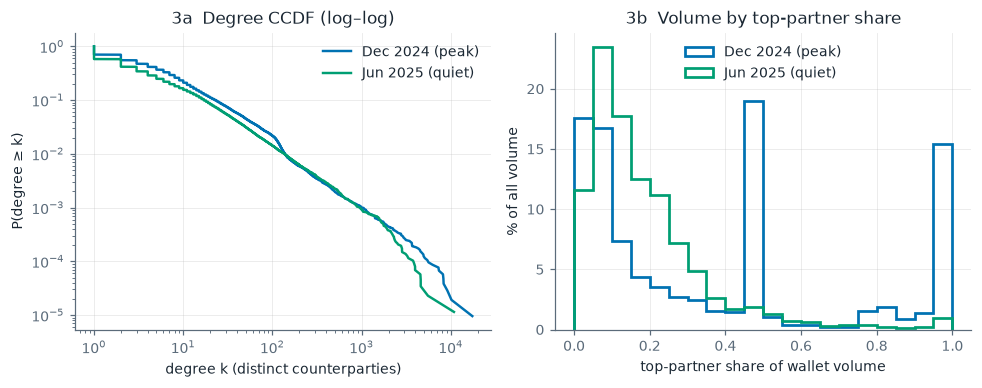

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
bins = np.linspace(0, 1, 21)
for w, d in deg.items():
    c, lab = WIN[w]["color"], WIN[w]["label"]
    # CCDF: sort degrees, P(degree >= x_i) = 1 - i/n
    x = np.sort(d["degree"].to_numpy())
    y = 1 - np.arange(len(x)) / len(x)
    ax1.loglog(x, y, color=c, lw=1.6, label=lab)
    # histogram of top-partner share, each wallet weighted by its volume, as % of all volume
    ax2.hist(d["top_partner_share"], bins=bins, weights=100 * d["vol"] / d["vol"].sum(),
             histtype="step", lw=1.8, color=c, label=lab)

    hi = d["top_partner_share"] >= 0.8
    top1 = d.nlargest(max(1, len(d) // 100), "vol")
    record_stat(w, "degree_median", d["degree"].median())
    record_stat(w, "degree_max", d["degree"].max())
    record_stat(w, "pct_wallets_degree_1", 100 * (d["degree"] == 1).mean())
    record_stat(w, "pct_volume_top_partner_ge_0.8", 100 * d.loc[hi, "vol"].sum() / d["vol"].sum())
    record_stat(w, "pct_volume_top1pct_wallets", 100 * top1["vol"].sum() / d["vol"].sum())

ax1.set(xlabel="degree k (distinct counterparties)", ylabel="P(degree ≥ k)",
        title="3a  Degree CCDF (log–log)")
ax2.set(xlabel="top-partner share of wallet volume", ylabel="% of all volume",
        title="3b  Volume by top-partner share")
ax1.legend(frameon=False)
ax2.legend(frameon=False, loc="upper center")
save_fig(fig, "03_degree")

pd.DataFrame({WIN[w]["label"]: {k: round(v, 2) for k, v in STATS[w].items()
                               if k.startswith(("degree", "pct_wallets_deg", "pct_volume_top"))}
              for w in WIN})

**อ่านผล:**

- **3a CCDF:** ทั้งสองช่วงเป็น**หางยาว** (เส้นเกือบตรงบน log–log ≈ power law) — กระเป๋าส่วนใหญ่มีคู่แค่ 1–10 ราย
  แต่มี hub (market maker / บอท) ที่เทรดกับคนเป็นหมื่น (สูงสุด 17,393 ราย) → เมทริกซ์ $B$ ของอัลกอริทึม**เบาบางมาก** แต่มี hub ไม่กี่ตัวที่เชื่อมทุกอย่าง
  ช่วงพีคมีกระเป๋า degree = 1 น้อยกว่า (30% vs 42%)
- **3b top-partner share (สำคัญที่สุด):** รูปร่างต่างกันชัด
  - ช่วงเงียบ: volume กองอยู่ที่ share **ต่ำ** (0.05–0.3) = กระเป๋าใหญ่เทรดกับคนหลากหลาย ซึ่งเป็นพฤติกรรมตลาดปกติ
  - ช่วงพีค: มี **ยอดสองยอด** ที่ช่วงเงียบไม่มี — ที่ **≈ 0.5** (19% ของ volume) และที่ **≈ 1.0** (15%)
  - volume จากกระเป๋าที่ top-partner share ≥ 0.8: **19.5% (พีค) vs 1.5% (เงียบ)** ต่างกัน ~13 เท่า
- **3c ความกระจุก:** ช่วงเงียบ top 1% ของกระเป๋าถือ 77% ของ volume (ตลาดถูก market maker รายใหญ่ครอง)
  ส่วนช่วงพีคแค่ 54% → ช่วงพีคมี**กระเป๋าขนาดกลางจำนวนมาก**ที่เทรดกับคู่จำกัด ซึ่งเข้ากับภาพ "ฟาร์มกระเป๋า" ของ wash
- **ส่งถึง B:** top-partner share เป็นฟีเจอร์ง่าย ๆ ที่แยกสองช่วงได้ดี ใช้เป็น sanity check หรือฟีเจอร์ของ Isolation Forest ได้

### 3.3 เจาะ spike ที่ top-partner share ≈ 0.5 ของช่วงพีค

**ทำไม:** กราฟ 3b ช่วง ธ.ค. มียอดแหลมที่ bin 0.45–0.50 ซึ่งช่วงเงียบไม่มี — top-partner share ≈ 0.5
แปลว่ากระเป๋าแบ่ง volume ครึ่ง ๆ ให้คู่อันดับ 1 และน่าจะให้คู่อันดับ 2 อีกครึ่ง → รูปแบบ **"โซ่/วง"**
(A ซื้อจาก B แล้วขายให้ C, หรือ A↔B↔C↔A) ซึ่งเป็นโครงสร้างคลาสสิกของ wash ring

**วิธี:** จัดอันดับคู่ของแต่ละกระเป๋าด้วย window function `row_number() OVER (PARTITION BY wallet ORDER BY v DESC)`
แล้วคำนวณ **top-2 partner share** = volume กับคู่อันดับ 1+2 ÷ volume ทั้งหมด
- ตารางแรก: กระเป๋าใน band 0.45–0.50 มีกี่ใบ / volume กี่ % / top-2 share เฉลี่ยถ่วง volume
- ตัวชี้วัดทั่วไปสำหรับ B: **% volume จากกระเป๋าที่ top-2 share ≥ 0.9** (ใช้แทน top-1 ที่พลาดวงสามกระเป๋า)
- ตารางที่สอง: กระเป๋าใหญ่สุดใน band พร้อมคู่ 2 อันดับแรก — ดูว่าคู่ของกันและกันวนกลับมาไหม

In [9]:
SQL_TOP2 = """
    WITH e AS ({edges}),
    r AS (
        SELECT wallet, partner, v,
               row_number() OVER (PARTITION BY wallet ORDER BY v DESC) AS rk
        FROM e
    )
    SELECT wallet,
           count(*)                                 AS degree,
           sum(v)                                   AS vol,
           max(v) FILTER (WHERE rk = 1) / sum(v)    AS s1,     -- top-1 partner share
           sum(v) FILTER (WHERE rk <= 2) / sum(v)   AS s12,    -- top-1 + top-2 partner share
           any_value(partner) FILTER (WHERE rk = 1) AS p1,
           any_value(partner) FILTER (WHERE rk = 2) AS p2
    FROM r
    GROUP BY 1
"""
top2 = {w: q(SQL_TOP2.format(edges=SQL_EDGES.format(t=trades(w)))) for w in WIN}

band_rows = {}
for w, d in top2.items():
    band = d[(d["s1"] >= 0.45) & (d["s1"] < 0.5)]
    hi2 = d["s12"] >= 0.9
    band_rows[WIN[w]["label"]] = {
        "wallets in band 0.45-0.50": len(band),
        "% volume in band": 100 * band["vol"].sum() / d["vol"].sum(),
        "band: vol-weighted top-2 share": (band["s12"] * band["vol"]).sum() / band["vol"].sum(),
        "% volume with top-2 share >= 0.9": 100 * d.loc[hi2, "vol"].sum() / d["vol"].sum(),
    }
    record_stat(w, "wallets_top1_share_045_050", len(band))
    record_stat(w, "pct_volume_top1_share_045_050", band_rows[WIN[w]["label"]]["% volume in band"])
    record_stat(w, "pct_volume_top2_share_ge_0.9", band_rows[WIN[w]["label"]]["% volume with top-2 share >= 0.9"])
display(pd.DataFrame(band_rows).round(3))

# biggest wallets in the Dec band, with their two main partners (addresses shortened)
d = top2["dec2024"]
band = d[(d["s1"] >= 0.45) & (d["s1"] < 0.5)].nlargest(10, "vol").copy()
band["mutual"] = [  # is this wallet also one of its top partner's two main partners?
    w in set(d.loc[d["wallet"] == p, ["p1", "p2"]].values.ravel()) for w, p in zip(band["wallet"], band["p1"])]
for col in ["wallet", "p1", "p2"]:
    band[col] = band[col].str[:10] + "…"
band.assign(vol_k=(band["vol"] / 1e3).round(1))[["wallet", "degree", "vol_k", "s1", "s12", "p1", "p2", "mutual"]].round(3)

,Dec 2024 (peak),Jun 2025 (quiet)
wallets in band 0.45-0.50,7035.000,3005.000
% volume in band,18.980,1.894
band: vol-weighted top-2 share,0.932,0.727
% volume with top-2 share >= 0.9,38.169,2.671


,wallet,degree,vol_k,s1,s12,p1,p2,mutual
33515,0x8f135f69…,4,1011.1,0.487,0.762,0x463e797d…,0x8bbae46e…,False
94508,0xd76a18e2…,142,813.0,0.468,0.589,0x47bc8458…,0x989b67c8…,True
61236,0x51158621…,34,440.3,0.489,0.677,0x44c1dfe4…,0x51fd8f03…,False
75494,0x16380959…,335,360.3,0.455,0.724,0x8beaea49…,0x676146d7…,True
16710,0xd18f887f…,27,326.3,0.478,0.648,0xd42f6a16…,0x2d27e4d2…,False
59469,0x3368a2f8…,10,259.4,0.475,0.947,0x61b60d28…,0x6043946c…,True
78611,0x9a7d5f23…,10,255.2,0.490,0.967,0x71c1f362…,0x4a84c3db…,True
46536,0xda0a2dd2…,8,253.8,0.489,0.946,0xa2c003d4…,0x4f9efef7…,True
62327,0x8bd7966c…,11,253.2,0.473,0.766,0x45f2efb7…,0x8bbae46e…,True
59909,0xdda503b7…,9,252.8,0.486,0.966,0xdb2178fa…,0x53e45387…,True


**อ่านผล:**

- ช่วงพีคมีกระเป๋า **7,036 ใบ** ใน band 0.45–0.50 คิดเป็น **19% ของ volume** (ช่วงเงียบ 1.9%) และกระเป๋าเหล่านี้มี
  **top-2 share เฉลี่ย 0.93** — คือ 93% ของ volume อยู่กับคู่แค่ 2 รายที่แบ่งครึ่งกันพอดี → รูปแบบ **"โซ่"** ที่รับจากคนหนึ่งแล้วส่งต่อให้อีกคน
- ตัวชี้วัดรวม **% volume จากกระเป๋าที่ top-2 share ≥ 0.9 = 38.2% (พีค) vs 2.7% (เงียบ)** — ต่างกัน ~14 เท่า
  และ 38% ใกล้กับระดับที่อัลกอริทึมติดธง (61.8%) มากกว่าตัวชี้วัด top-1 (19.5%) → วง/โซ่หลายกระเป๋าเป็นส่วนสำคัญของ wash
- ตารางกระเป๋าใหญ่สุดใน band: **7 ใน 10 เป็น `mutual`** (กระเป๋านี้ก็เป็นคู่หลักของคู่ของมันด้วย) → คู่เดิมวนกลับมาหากันจริง
  และหลายใบมี volume **≈ 250–260 k หุ้นเท่ากันเกือบเป๊ะ** ทั้งที่ degree แค่ 8–11 → ดูเหมือนบอทชุดเดียวกันที่ตั้งเป้า volume ไว้
- **ส่งถึง B:** กระเป๋ากลุ่มนี้ควรถูกอัลกอริทึมติดธงเกือบทั้งหมด — ใช้เป็น **ชุดตรวจ (spot check)** ได้: ถ้าผลของ B ไม่ติดธงพวกนี้ แปลว่ามีอะไรผิด

## 4. หมวดตลาด: volume กระจุกที่ไหน

**คำถาม:** volume ของสัปดาห์เป้าหมายแบ่งเป็นหมวด Sports / Politics / Crypto / Economy / Other อย่างละกี่ %
เทียบสองช่วง · เปเปอร์พบว่าตลาดกีฬามี wash ~45% ของ volume และผล premise test ของเราก็เจอ wash หนักในตลาดกีฬาโอกาสน้อย

**ปัญหาข้อมูล:** `market_data` **ไม่มีคอลัมน์หมวด** (มีแค่ชื่อ, slug, คำอธิบาย, วันเปิด/ปิด)
→ ต้อง **จัดหมวดเองด้วยคีย์เวิร์ด** จาก `marketName` + `marketSlug` (ต้องบอกในสไลด์ว่าเป็นการจัดหมวดของเราเอง)

### 4.1 กฎจัดหมวดด้วยคีย์เวิร์ด

**รายละเอียดที่ต้องระวัง:**
- **join ซ้ำ:** `market_data` มี **หลายแถวต่อ condition** (หนึ่งแถวต่อ token Yes/No) → ต้อง `GROUP BY condition`
  ก่อน join ไม่งั้น volume จะถูกนับซ้ำ 2 เท่า
- **ลำดับใน `CASE WHEN` สำคัญ** — กฎแรกที่ match ชนะ เราเรียง Crypto → Sports → Economy → Politics เพราะ
  - "Ansem vs. Bitboy – Crypto Fight Night" ควรเป็น Crypto ไม่ใช่ Sports (คำว่า *vs*, *fight*)
  - "Ohio State make the College Football Playoff" ต้องเป็น Sports ก่อนที่คำว่า *state* ของ Politics จะจับ
  - ข้อแลกเปลี่ยน: "Will Trump say Bitcoin…" จะไป Crypto — ยอมรับได้เพราะมี volume น้อย
- ใช้ `lower(...)` + regex แบบมีขอบคำ `\b` ไม่งั้น "nba" จะ match กลางคำอื่น และ "eth" จะ match ใน "Bethesda"
- คีย์เวิร์ดได้มาจากการไล่ดู top ตลาดตาม volume ของทั้งสองช่วงแล้วเพิ่มจนหมวด Other เหลือน้อย (ดู 4.3)

cell นี้แค่ **นิยาม SQL** ยังไม่รัน — ใช้ซ้ำใน cell ถัดไป

In [10]:
# Order matters: the first WHEN that matches wins (see the notes above).
SQL_CATEGORY = r"""
    WITH md AS (
        SELECT condition,
               lower(coalesce(any_value(marketName), '') || ' ' ||
                     coalesce(any_value(marketSlug), '')) AS txt
        FROM '{markets}'
        GROUP BY condition                       -- one row per market, avoids double counting
    )
    SELECT condition AS market,
           CASE
             WHEN regexp_matches(txt, '\b(bitcoin|btc|eth|ethereum|solana|sol|xrp|ripple|doge|dogecoin|crypto|memecoin|token|airdrop|fdv|binance|coinbase|microstrategy|usdc|usdt|tether|pepe|hyperliquid|ansem|bitboy)\b')
                  THEN 'Crypto'
             WHEN regexp_matches(txt, '\b(nba|nfl|nhl|mlb|wnba|ncaa|ufc|mma|super bowl|stanley cup|premier league|champions league|la liga|serie a|bundesliga|ligue 1|uefa|fifa|f1|formula 1|grand prix|drivers champion|college football|afc|nfc|mvp|playoffs?|finals|championship|french open|wimbledon|us open|tennis|golf|pga|boxing|fight|vs\.?|fantasy|heisman|world series|cricket|olympics?|chess|liverpool|everton|arsenal|chelsea|manchester|tottenham|real madrid|barcelona)\b')
                  THEN 'Sports'
             WHEN regexp_matches(txt, '\b(fed|interest rates?|bps|inflation|cpi|gdp|recession|unemployment|jobs report|tariffs?|s&p|nasdaq|stocks?|ipo|treasury|gold|oil)\b')
                  THEN 'Economy'
             WHEN regexp_matches(txt, '\b(trump|biden|harris|elon musk create|election|elected|president|presidential|prime minister|senate|house|governor|mayor|primary|democrat\w*|republican\w*|parliament|votes?|cabinet|secretary|inaugurated|ceasefire|war|invade|invasion|nato|putin|zelensk\w*|israel|hamas|hezbollah|gaza|iran|ukraine|russia|assad|syria|yoon|tipping point|state|congress|impeach\w*|pope|nawrocki|trzaskowski|jae-myung|moon-soo|jun-seok)\b')
                  THEN 'Politics'
             ELSE 'Other'
           END AS category
    FROM md
""".format(markets=MARKETS)
CATS = ["Sports", "Politics", "Crypto", "Economy", "Other"]
print("category rule defined;", len(CATS), "categories")

category rule defined; 5 categories


### 4.2 สัดส่วน volume ต่อหมวด

**ทำอะไร:** join ตารางเทรดสัปดาห์เป้าหมายกับผลจัดหมวด แล้วรวม volume ต่อหมวด แปลงเป็น % ของทั้งสัปดาห์
พร้อมนับจำนวนตลาดต่อหมวด · `assert` ตรวจว่า % รวมได้ 100 และ volume หลัง join ไม่หาย/ไม่ซ้ำ
(เทียบกับ `share_volume_M` จากหัวข้อ 1 — ถ้า join ซ้ำ ตัวเลขจะเกิน)

In [11]:
cat_rows = []
for w in WIN:
    c = q(f"""
        SELECT c.category,
               sum(t.shares) / 1e6     AS share_volume_M,
               count(DISTINCT market)  AS markets
        FROM '{trades(w)}' t
        LEFT JOIN ({SQL_CATEGORY}) c USING (market)
        WHERE t.in_target
        GROUP BY 1
    """).set_index("category").reindex(CATS).fillna(0)
    # the join must neither lose nor duplicate volume
    assert abs(c["share_volume_M"].sum() - STATS[w]["share_volume_M"]) < 1e-6, w
    c["pct_volume"] = 100 * c["share_volume_M"] / c["share_volume_M"].sum()
    assert abs(c["pct_volume"].sum() - 100) < 1e-9
    for k, v in c["pct_volume"].items():
        record_stat(w, f"pct_volume_{k.lower()}", v)
    c.columns = pd.MultiIndex.from_product([[WIN[w]["label"]], c.columns])
    cat_rows.append(c)

cat = pd.concat(cat_rows, axis=1)
cat.round(1)

Dec 2024 (peak)                    Jun 2025 (quiet)          \
          share_volume_M markets pct_volume   share_volume_M markets   
category                                                               
Sports             396.0     974       57.1             62.8     947   
Politics           195.7     602       28.2            225.8     929   
Crypto              65.4     160        9.4             56.7     555   
Economy             10.0      58        1.4             22.8     165   
Other               25.8     513        3.7             21.7    1322   

                     
         pct_volume  
category             
Sports         16.1  
Politics       57.9  
Crypto         14.5  
Economy         5.8  
Other           5.6

**อ่านผล:**

- **assert ผ่าน:** volume หลัง join เท่ากับหัวข้อ 1 พอดี (group ก่อน join ได้ผล ไม่มี volume ซ้ำ) และ % รวมได้ 100
- ช่วงพีค: **Sports 57%** ของ volume จากตลาดเพียง 974 ตลาด
- ช่วงเงียบ: **Politics 58%** (เลือกตั้งเกาหลีใต้ + โปแลนด์ในสัปดาห์เดียวกัน) Sports เหลือแค่ 16%
- ช่วงเงียบมีตลาด Other มากถึง 1,322 ตลาด แต่ volume รวมแค่ 5.6% → ตลาดเล็กจำนวนมาก (เช่น จำนวนทวีตของ Elon)

### 4.3 ตรวจหมวด Other และวาดกราฟ

**ทำไมต้องตรวจ Other:** ถ้า Other ใหญ่ (> ~30%) แปลว่ากฎคีย์เวิร์ดพลาดตลาดสำคัญ และ % ของหมวดอื่นจะต่ำผิดจริง
จึงพิมพ์ top-8 ตลาดใน Other ตาม volume ของแต่ละช่วงให้เห็นว่าเหลืออะไรอยู่

**กราฟ:** stacked bar แนวนอน 100% สองแท่ง — ดูสัดส่วนหมวดเทียบกันระหว่างสองช่วงได้ทันที

--- Dec 2024 (peak): biggest 'Other' markets ---
 share_volume_M                                                           name
           3.32              Will "Moana 2" have a Tomatometer score of 75-79?
           1.97 Will MrBeast x Ronaldo video get less than 50m views on day 1?
           1.21                               2024 November hottest on record?
           0.77                        Will 'Dune: Part 2' gross most in 2024?
           0.74              Will 'Moana 2' gross over $200m on 5-day opening?
           0.72                         Will another movie gross most in 2024?
           0.71                Global heat increase less than 1.22°C for 2024?
           0.71                     Will 'Despicable Me 4' gross most in 2024?


--- Jun 2025 (quiet): biggest 'Other' markets ---
 share_volume_M                                                                                      name
           0.67                                          Will Elon tweet 350 or more times May 30–June 6?
           0.56                                          Will Elon tweet 230 or more times May 30–June 6?
           0.42                               Will MrBeast's next video get less than 20m views on day 1?
           0.42                                              Will Elon tweet 320–334 times May 30–June 6?
           0.35                                              Will Elon tweet 185–199 times May 30–June 6?
           0.34                                              Will Elon tweet 215–229 times May 30–June 6?
           0.33                                              Will Elon tweet 200–214 times May 30–June 6?
           0.32 Will "From the World of John Wick: Ballerina" Opening Weekend Box Office be $37m or mo

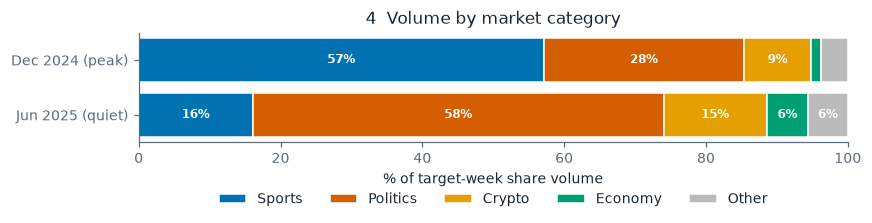

In [12]:
for w in WIN:
    other = q(f"""
        WITH v AS (
            SELECT market, sum(shares) / 1e6 AS share_volume_M
            FROM '{trades(w)}' t JOIN ({SQL_CATEGORY}) c USING (market)
            WHERE t.in_target AND c.category = 'Other'
            GROUP BY 1)
        SELECT round(v.share_volume_M, 2) AS share_volume_M, any_value(md.marketName) AS name
        FROM v JOIN '{MARKETS}' md ON md.condition = v.market
        GROUP BY v.market, v.share_volume_M
        ORDER BY 1 DESC LIMIT 8
    """)
    print(f"--- {WIN[w]['label']}: biggest 'Other' markets ---")
    print(other.to_string(index=False))

cat_colors = {"Sports": C_DATA, "Politics": C_ALG, "Crypto": "#E69F00",
              "Economy": C_EVAL, "Other": "#BBBBBB"}
fig, ax = plt.subplots(figsize=(8, 2.4))
labels = [WIN[w]["label"] for w in WIN]
left = np.zeros(len(labels))
for k in CATS:
    vals = np.array([cat[(lab, "pct_volume")][k] for lab in labels])
    ax.barh(labels, vals, left=left, color=cat_colors[k], label=k, edgecolor="white")
    for i, v in enumerate(vals):
        if v >= 5:   # label only segments wide enough to read
            ax.text(left[i] + v / 2, i, f"{v:.0f}%", ha="center", va="center",
                    color="white", fontsize=8, fontweight="bold")
    left += vals
ax.set(xlim=(0, 100), xlabel="% of target-week share volume", title="4  Volume by market category")
ax.invert_yaxis()
ax.grid(False)
ax.legend(ncol=5, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.35))
save_fig(fig, "04_category_share")

**อ่านผล:**

- **หมวด Other เหลือ 3.7% (ธ.ค.) และ 5.6% (มิ.ย.)** ต่ำกว่าเกณฑ์ 30% มาก → กฎคีย์เวิร์ดใช้ได้ ตลาดที่เหลือเป็นหนัง/ยูทูบ/สภาพอากาศ/จำนวนทวีต ซึ่งเป็นหมวด "pop culture" จริง ๆ
- **ตลาดกีฬาครอง volume ช่วงพีค (57%) แต่เหลือแค่ 16% ในช่วงเงียบ** — volume กีฬาลดจาก ~396 M เหลือ ~63 M หุ้น (−84%)
  ในขณะที่ volume การเมืองแทบเท่าเดิม (196 M → 226 M) → **volume ที่หายไปเมื่อ wash หยุด คือ volume กีฬาเกือบทั้งหมด**
- สอดคล้องกับเปเปอร์ (Sports มี wash สูง) และผล premise test (top ตลาดที่ถูกติดธงคือทีมบ๊วยชิงแชมป์ เช่น Blackhawks, Sharks, Falcons)
- **ข้อควรระวังในสไลด์:** หมวดเป็นการจัดเองด้วยคีย์เวิร์ด ไม่ใช่หมวดทางการของ Polymarket — เทียบกับตัวเลขรายหมวดของเปเปอร์ได้แค่เชิงทิศทาง

## 5. ราคาและขนาดเทรด

### 5.1 (5a) การกระจายราคาถ่วงด้วย volume

**คำถาม:** volume กี่ % ถูกเทรดที่ราคา < 0.05 (ตลาด "โอกาสน้อย" เช่นทีมบ๊วยจะได้แชมป์) หรือ > 0.95 (ผลแทบแน่นอนแล้ว)

**ทำไมสำคัญ:** wash trader ต้องการปั่น *share volume* ด้วยเงินน้อยที่สุด token ราคา 0.01 USDC
ทำให้ซื้อขายได้ 100 หุ้นด้วยเงินแค่ 1 USDC → ถ้า wash อยู่จริง ช่วงพีคควรมี volume กองที่ราคาต่ำมากกว่าช่วงเงียบ

**วิธี:**
- ราคาต่อเทรด = `usdc / shares` คือราคาของ **token ที่เทรดจริง** (Yes หรือ No) — ตอบได้ว่า "ถูกหรือแพง" ตรง ๆ
  (ถ้าจะแปลเป็นความน่าจะเป็นที่ Yes ชนะ ต้องกลับฝั่ง No เป็น `1 − p` ซึ่งไม่จำเป็นสำหรับคำถามนี้)
- ให้ DuckDB ตัด bin กว้าง 0.01 ก่อน (`floor(p * 100) / 100`) → 100 แถวต่อหน้าต่าง ไม่ต้องดึงล้านแถวมา plot
- กัน `shares = 0` (หารศูนย์) ด้วย `AND shares > 0`
- ใช้ **% ของ volume** ต่อ bin ไม่ใช่จำนวนเทรด ไม่งั้นเทรดเล็กจำนวนมากจะกลบภาพ

In [13]:
SQL_PRICE_BINS = """
    SELECT least(floor(usdc / shares * 100) / 100, 0.99) AS price_bin,   -- 0.00, 0.01, ..., 0.99
           sum(shares) / 1e6                             AS share_volume_M,
           count(*)                                      AS trades
    FROM '{t}'
    WHERE in_target AND shares > 0
    GROUP BY 1 ORDER BY 1
"""
price = {}
for w in WIN:
    p = q(SQL_PRICE_BINS.format(t=trades(w)))
    p["pct_volume"] = 100 * p["share_volume_M"] / p["share_volume_M"].sum()
    price[w] = p
    record_stat(w, "pct_volume_price_lt_0.05", p.loc[p["price_bin"] < 0.05, "pct_volume"].sum())
    record_stat(w, "pct_volume_price_gt_0.95", p.loc[p["price_bin"] >= 0.95, "pct_volume"].sum())
    record_stat(w, "pct_volume_price_lt_0.02", p.loc[p["price_bin"] < 0.02, "pct_volume"].sum())

pd.DataFrame({WIN[w]["label"]: {k: round(STATS[w][k], 1) for k in
              ["pct_volume_price_lt_0.02", "pct_volume_price_lt_0.05", "pct_volume_price_gt_0.95"]}
              for w in WIN})

,Dec 2024 (peak),Jun 2025 (quiet)
pct_volume_price_lt_0.02,62.6,25.2
pct_volume_price_lt_0.05,64.3,33.0
pct_volume_price_gt_0.95,15.5,22.4


ตารางนี้คือสัดส่วน volume ที่ปลายทั้งสองข้างของช่วงราคา (`price_lt_0.02` = ราคาต่ำกว่า 2 เซนต์ต่อหุ้น คือ bin 0.00 และ 0.01)
กราฟถัดไปแสดงทั้งการกระจาย — แกน y เป็น **log** เพราะ bin ปลายสูงกว่า bin กลางหลายสิบเท่า
ถ้าใช้แกนปกติ bin กลางทั้งหมดจะแบนติดพื้น

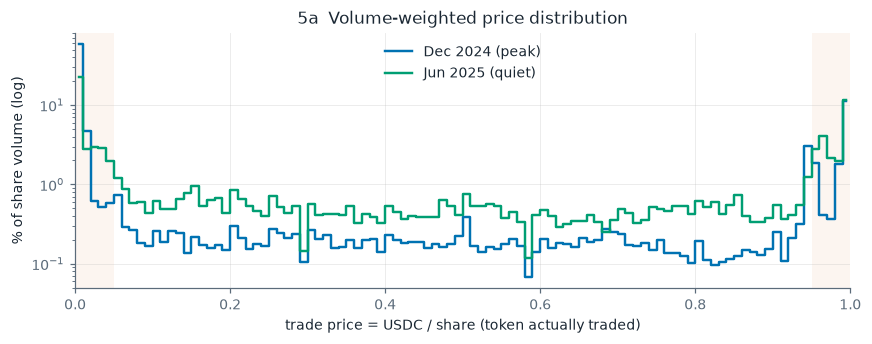

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.2))
for w, p in price.items():
    ax.step(p["price_bin"] + 0.005, p["pct_volume"], where="mid",
            color=WIN[w]["color"], lw=1.6, label=WIN[w]["label"])
ax.set_yscale("log")
ax.axvspan(0, 0.05, color=C_ALG, alpha=0.06, lw=0)
ax.axvspan(0.95, 1, color=C_ALG, alpha=0.06, lw=0)
ax.set(xlim=(0, 1), xlabel="trade price = USDC / share (token actually traded)",
       ylabel="% of share volume (log)", title="5a  Volume-weighted price distribution")
ax.legend(frameon=False)
save_fig(fig, "05a_price")

**อ่านผล:**

- ช่วงพีค **62.6% ของ volume ถูกเทรดที่ราคา < 0.02 USDC** (และ 64.3% ที่ < 0.05) เทียบกับช่วงเงียบ 25.2% (33.0%)
  → กราฟเป็นรูป "U" ทั้งคู่ (ตลาดที่ใกล้ตัดสินมีราคาอยู่ที่ปลาย) แต่**ปลายซ้ายของช่วงพีคสูงกว่ามาก**
  และช่วงกลาง (0.1–0.9) ของช่วงพีคต่ำกว่าช่วงเงียบเกือบทุก bin
- ยืนยันกลไก: token ราคา 0.01 ทำให้ปั่น 1 ล้านหุ้นด้วยเงินแค่ ~10,000 USDC — share volume ช่วงพีคจึงพองโดย USDC volume แทบไม่เพิ่ม (หัวข้อ 1)
- ปลายขวา (> 0.95) ช่วงเงียบสูงกว่า (22% vs 16%) — เป็นการเทรดปกติในตลาดที่ผลใกล้แน่นอนแล้ว
- **ส่งถึง B:** ตรงกับที่ wash อยู่ในตลาดโอกาสน้อย (ผล premise test) ถ้าจะทำ Isolation Forest ราคาเฉลี่ยของกระเป๋าเป็นฟีเจอร์ที่ดี

### 5.2 (5b) ขนาดเทรด

**คำถาม:** ขนาดเทรด (`shares`) กระจายอย่างไร และมี **ขนาดไหนเกิดซ้ำผิดปกติ** ไหม
(บอทมักเทรดขนาดคงที่เป๊ะ ๆ ซ้ำหลายพันครั้ง ส่วนคนจริงจะกระจายกว่า)

**วิธี:**
- ขนาดเทรดเป็นหางยาวมาก (0.01 ถึงหลักแสนหุ้น) → ทำ bin บน `log10(shares)` กว้าง 0.1 (10 bin ต่อหนึ่งหลัก)
- ตาราง top-10 **ขนาดที่ตรงกันเป๊ะ** ที่เกิดบ่อยที่สุด พร้อม % ของจำนวนเทรด และราคาเฉลี่ย

In [15]:
size_bins, top_sizes = {}, {}
for w in WIN:
    t = trades(w)
    s = q(f"""
        SELECT floor(log10(shares) * 10) / 10 AS log10_bin, count(*) AS trades
        FROM '{t}' WHERE in_target AND shares > 0
        GROUP BY 1 ORDER BY 1
    """)
    s["pct_trades"] = 100 * s["trades"] / s["trades"].sum()
    size_bins[w] = s
    top = q(f"""
        SELECT shares, count(*) AS trades,
               100.0 * count(*) / sum(count(*)) OVER () AS pct_trades,
               sum(usdc) / sum(shares)                  AS avg_price
        FROM '{t}' WHERE in_target
        GROUP BY 1
        ORDER BY trades DESC LIMIT 10
    """)
    top_sizes[w] = top
    record_stat(w, "most_common_size", top.iloc[0]["shares"])
    record_stat(w, "most_common_size_pct_trades", top.iloc[0]["pct_trades"])

pd.concat({WIN[w]["label"]: top_sizes[w].round(3).reset_index(drop=True) for w in WIN}, axis=1)

Dec 2024 (peak)                             Jun 2025 (quiet)         \
           shares trades pct_trades avg_price           shares trades   
0            96.0  72855      4.455     0.986            100.0  54250   
1            10.0  38069      2.328     0.315             10.0  53765   
2            50.0  32730      2.002     0.454              5.0  33571   
3            20.0  29047      1.776     0.349             20.0  31424   
4             5.0  28544      1.746     0.376             50.0  24537   
5           100.0  27580      1.687     0.409            200.0  21008   
6            30.0  24616      1.505     0.581             30.0  17530   
7            11.0  23479      1.436     0.065            500.0  16650   
8            40.0  11332      0.693     0.435            300.0  11191   
9            60.0  10177      0.622     0.519              6.0  11143   

                        
  pct_trades avg_price  
0      4.729     0.431  
1      4.687     0.466  
2      2.926     0.432  
3      2.739     0.359  
4      2.139     0.391  
5      1.831     0.440  
6      1.528     0.316  
7      1.451     0.470  
8      0.976     0.433  
9      0.971     0.407

ตารางด้านบนวางสองหน้าต่างคู่กัน: แต่ละแถวคือขนาดเทรดที่พบบ่อยอันดับ 1–10 ของช่วงนั้น
ส่วนกราฟถัดไปคือ histogram ของ `log10(shares)` (แกน x แปลงกลับเป็นจำนวนหุ้นให้อ่านง่าย)

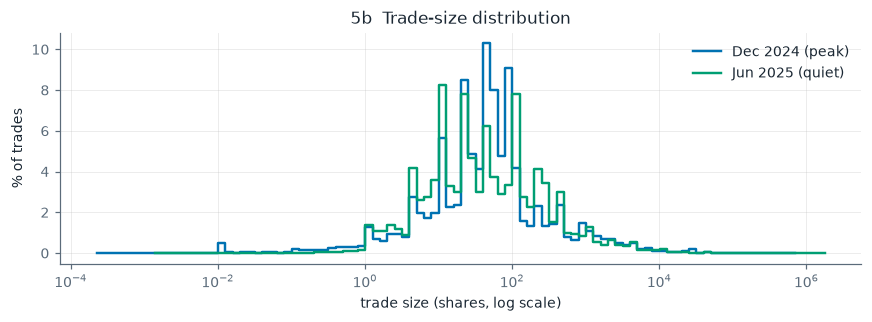

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.0))
for w, s in size_bins.items():
    ax.step(10 ** (s["log10_bin"] + 0.05), s["pct_trades"], where="mid",
            color=WIN[w]["color"], lw=1.6, label=WIN[w]["label"])
ax.set_xscale("log")
ax.set(xlabel="trade size (shares, log scale)", ylabel="% of trades",
       title="5b  Trade-size distribution")
ax.legend(frameon=False)
save_fig(fig, "05b_trade_size")

**อ่านผล:**

- รูปร่างการกระจายโดยรวมคล้ายกัน (ยอดราว 10–100 หุ้น) ยอดแหลมที่เห็นคือ**เลขกลม** (5, 10, 20, 50, 100, 200, 500) ที่คนพิมพ์เอง — เป็นเรื่องปกติ
- ช่วงเงียบ: top ขนาดเป็นเลขกลมทั้งหมด (100, 10, 5, 20, 50, 200, …)
- ช่วงพีค: **อันดับ 1 คือ 96 หุ้นพอดี (72,855 เทรด = 4.5% ของทุกเทรด)** ราคาเฉลี่ย 0.986 — ไม่ใช่เลขกลม ไม่ใช่สิ่งที่คนเลือกเอง
  และ 11 หุ้น (23,479 เทรด) ที่ราคาเฉลี่ยแค่ 0.065 ก็แปลก → เจาะดูต่อใน 5.3

### 5.3 (5c) เจาะดูเทรดขนาด 96 หุ้นของช่วงพีค

**ทำไม:** ในตาราง 5b ขนาด 96 หุ้นเป็นอันดับ 1 ของช่วง ธ.ค. ทั้งที่ไม่ใช่เลขกลม (10, 50, 100)
ซึ่งปกติคนจริงจะเลือก — ราคาเฉลี่ย ~0.99 ทำให้แต่ละเทรดมีมูลค่า ≈ 95 USDC ซึ่งน่าจะเป็นค่าที่บอทตั้งไว้

**คำถาม:** เทรด 96 หุ้นมาจากกระเป๋าไม่กี่ใบ (บอทตัวเดียว) หรือกระจายหลายใบ · อยู่ในตลาดไหน · ช่วงเงียบมีไหม

In [17]:
s96 = {}
for w in WIN:
    s96[w] = q(f"""
        SELECT count(*)                                                AS trades,
               count(DISTINCT maker)                                   AS makers,
               count(DISTINCT taker)                                   AS takers,
               count(DISTINCT least(maker, taker) || greatest(maker, taker)) AS pairs,
               count(DISTINCT market)                                  AS markets,
               sum(usdc) / sum(shares)                                 AS avg_price
        FROM '{trades(w)}' WHERE in_target AND shares = 96
    """).iloc[0].rename(WIN[w]["label"])
    record_stat(w, "trades_size_96", s96[w]["trades"])
display(pd.DataFrame(s96).T.round(3))

q(f"""
    WITH x AS (SELECT market, count(*) AS trades
               FROM '{trades("dec2024")}' WHERE in_target AND shares = 96 GROUP BY 1)
    SELECT x.trades, any_value(md.marketName) AS name
    FROM x JOIN '{MARKETS}' md ON md.condition = x.market
    GROUP BY x.market, x.trades
    ORDER BY 1 DESC LIMIT 8
""")

,trades,makers,takers,pairs,markets,avg_price
dec2024,72855.0,1195.0,1272.0,33198.0,195.0,0.986
jun2025,463.0,184.0,242.0,387.0,276.0,0.368


,trades,name
0,7049,Will Indiana make the College Football Playoff?
1,5506,Will Ohio State make the College Football Playoff?
2,4141,Will Russia use a nuclear weapon in 2024?
3,4037,Will Penn State make the College Football Playoff?
4,3841,Global heat increase less than 1.22°C for 2024?
5,3779,Will Notre Dame make the College Football Playoff?
6,3476,"Will Gold close at $3,200 or more at the end of 2024?"
7,2954,Will Tulane make the College Football Playoff?


**อ่านผล:**

- เทรด 96 หุ้น: **72,855 ครั้งในช่วงพีค vs 463 ครั้งในช่วงเงียบ** (~160 เท่า) — เป็นพฤติกรรมเฉพาะช่วงพีค
- มาจาก ~1,200 maker / ~1,270 taker และ **33,198 คู่** — ไม่ใช่บอทตัวเดียวที่เทรดกับคู่เดิม แต่เป็น**กลุ่มกระเป๋าจำนวนมากที่ใช้ขนาดเดียวกัน**
  (อาจเป็นเครื่องมือ/สคริปต์ตัวเดียวกันที่รันบนหลายกระเป๋า)
- ราคา ~0.99 และอยู่ในตลาดที่**ผลแทบแน่นอนแล้ว** เช่น "Will Indiana / Ohio State make the College Football Playoff?",
  "Russia use a nuclear weapon in 2024?" → ไม่มีเหตุผลทางการเดิมพันที่จะซื้อขายซ้ำหลายพันครั้งที่ราคานี้
  แต่ volume ต่อเงินที่เสี่ยงต่ำมาก (ราคาแทบไม่ขยับ) ซึ่งเข้ากับ **wash เพื่อปั่น volume / ฟาร์ม reward หรือ airdrop**
- ข้อแตกต่างจาก wash ที่ราคาต่ำ: ที่นี่ราคาสูง (~95 USDC ต่อเทรด) แต่ความเสี่ยงต่ำพอกัน — ควรบอกในสไลด์ว่า wash มีอย่างน้อย 2 แบบ
- **ส่งถึง B:** เช็กว่าเทรด 96 หุ้นถูกอัลกอริทึมติดธงกี่ % — ถ้าต่ำ อาจเป็น wash แบบที่ closure test จับไม่ได้ (เช่นซื้อแล้วถือจนตลาดปิด)

## 6. อายุตลาดเทียบหน้าต่างเวลา (ส่ง A)

**ทำไมสำคัญ:** Algorithm 1 ต้องรู้ **position ของกระเป๋าตั้งแต่ตลาดเปิด** เพื่อดูว่ากระเป๋าเปิด–ปิด position (closure)
หรือไม่ แต่เรามีข้อมูลย้อนแค่ lead-in 1 เดือน ตลาดที่ **เปิดก่อน lead-in** จึงไม่รู้ position ตั้งต้น
→ closure อาจถูกนับผิด และคะแนน wash ของตลาดนั้นเพี้ยน (ดูกรณีตลาด Trump ที่ถูกติดธง 89%)

### 6.1 (6a) ตลาดที่เปิดก่อน lead-in มีสัดส่วนเท่าไร

**วิธี:** รวม volume ต่อตลาดในสัปดาห์เป้าหมาย → join `market_data` (group ก่อน กันซ้ำ) เอา `startDate` ที่เก่าสุด
→ ติดป้าย `opened_before_leadin` ถ้า `startDate < lead_start`

**หมายเหตุ:** `startDate` เป็น **ข้อความ** ISO-8601 เทียบแบบ string กับ `'2024-11-01'` ได้เลยเพราะรูปแบบเรียงตามเวลาอยู่แล้ว
ตลาดที่ไม่มี `startDate` (NULL) จะได้ป้ายเป็น NULL — นับเป็น "ไม่ได้เปิดก่อน" ใน `.mean()` ซึ่งเป็นการประมาณแบบระวังน้อย (มีแค่ไม่กี่ตลาด)

In [18]:
SQL_MARKET_AGE = """
    WITH m AS (
        SELECT market, sum(shares) AS v
        FROM '{t}' WHERE in_target GROUP BY 1
    ),
    md AS (
        SELECT condition, any_value(marketName) AS name, min(startDate) AS start_date
        FROM '{markets}' GROUP BY 1
    )
    SELECT m.market, md.name, md.start_date, m.v,
           coalesce(md.start_date < '{lead}', false) AS opened_before_leadin
    FROM m LEFT JOIN md ON md.condition = m.market
"""

age = {}
for w, cfg in WINDOWS.items():
    age[w] = q(SQL_MARKET_AGE.format(t=trades(w), markets=MARKETS, lead=cfg["lead_start"]))
    a = age[w]
    pct_mk = 100 * a["opened_before_leadin"].mean()
    pct_vol = 100 * a.loc[a["opened_before_leadin"], "v"].sum() / a["v"].sum()
    record_stat(w, "pct_markets_opened_before_leadin", pct_mk)
    record_stat(w, "pct_volume_in_markets_opened_before_leadin", pct_vol)
    record_stat(w, "markets_with_name", int(a["name"].fillna("").ne("").sum()))
    record_stat(w, "markets_without_start_date", int(a["start_date"].isna().sum()))
    print(f"{w}: {pct_mk:.1f}% of markets / {pct_vol:.1f}% of volume opened before lead-in "
          f"({cfg['lead_start']}) · named markets {STATS[w]['markets_with_name']}/{len(a)} · "
          f"no startDate {STATS[w]['markets_without_start_date']}")

dec2024: 42.2% of markets / 69.7% of volume opened before lead-in (2024-11-01) · named markets 2307/2307 · no startDate 0


jun2025: 35.4% of markets / 52.6% of volume opened before lead-in (2025-05-01) · named markets 3898/3918 · no startDate 0


**อ่านผล:**

- ช่วงพีค: ตลาดที่เปิดก่อน lead-in = **42% ของตลาด แต่ 70% ของ volume** · ช่วงเงียบ 35% / 53%
  → ตลาดเก่าคือตลาดใหญ่ (ตลาดแชมป์ฤดูกาลที่เปิดมาหลายเดือน) ปัญหาขอบหน้าต่าง**ใหญ่กว่าที่คิดไว้มาก**
- ทางเลือก "กรองเฉพาะตลาดที่อายุอยู่ในช่วง" จะ**ทิ้ง volume 70%** ของช่วงพีค — ไม่ควรใช้เป็นทางหลัก
- ตลาดในสัปดาห์เป้าหมายมีชื่อครบ (2,307/2,307 และ 3,898/3,918) และมี `startDate` ครบ → ปัญหา "ตลาดไร้ชื่อ 39%" ที่เคยรายงาน
  เป็นตัวเลขของ**ทั้งตาราง** `market_data` ไม่ใช่ของหน้าต่างเรา

### 6.2 (6b) top-15 ตลาดเก่าตาม volume

**ทำอะไร:** จากตลาดที่เปิดก่อน lead-in ของช่วง ธ.ค. เลือก 15 อันดับแรกตาม volume แล้วคำนวณว่า **เปิดมาแล้วกี่วันก่อน lead-in**
และเช็กว่าตลาด "Will Donald Trump be inaugurated?" อยู่ในรายการไหม
(สมมติฐานเดิมคือตลาดนี้ถูกติดธง 89% เพราะเปิดก่อน lead-in จนไม่รู้ position ตั้งต้น)

แปลงข้อความเป็นเวลาด้วย `pd.to_datetime(..., utc=True, format="ISO8601")` ก่อนลบกัน —
ต้องระบุ `format="ISO8601"` เพราะบางแถวมีเศษวินาที (`...:44.053Z`) บางแถวไม่มี (`...:00Z`) ถ้าไม่ระบุ pandas จะเดารูปแบบจากแถวแรกแล้วพังที่แถวอื่น

ตารางนี้ใช้ตัดสินว่าถ้าจะครอบคลุมตลาดใหญ่ ๆ ต้องย้อนข้อมูลไปไกลแค่ไหน

In [19]:
def old_markets(w: str, n: int = 15) -> pd.DataFrame:
    lead = pd.Timestamp(WINDOWS[w]["lead_start"], tz="UTC")
    a = age[w].query("opened_before_leadin").copy()
    a["share_volume_M"] = a["v"] / 1e6
    a["pct_of_week"] = 100 * a["v"] / age[w]["v"].sum()
    a["days_before_leadin"] = (lead - pd.to_datetime(a["start_date"], utc=True, format="ISO8601")).dt.days
    a["start"] = pd.to_datetime(a["start_date"], utc=True, format="ISO8601").dt.strftime("%Y-%m-%d")
    return a.nlargest(n, "v")[["name", "start", "days_before_leadin", "share_volume_M", "pct_of_week"]]


top_old = old_markets("dec2024")
trump = age["dec2024"][age["dec2024"]["name"].str.contains("Trump be inaugurated", na=False)]
# hours from lead-in start to market open: > 0 means the market opened INSIDE our data
trump_open = pd.to_datetime(trump["start_date"], utc=True, format="ISO8601").iloc[0]
trump_hours = (trump_open - pd.Timestamp(WINDOWS["dec2024"]["lead_start"], tz="UTC")).total_seconds() / 3600
record_stat("dec2024", "top15_old_markets_pct_volume", top_old["pct_of_week"].sum())
record_stat("dec2024", "trump_inaugurated_opened_hours_after_leadin_start", trump_hours)
print(f"Trump-inauguration market: opened {trump_open:%Y-%m-%d %H:%M} UTC = {trump_hours:.1f} h AFTER "
      f"the lead-in start -> opened before lead-in? {bool(trump['opened_before_leadin'].iloc[0])}")
print(f"top-15 old markets = "
      f"{top_old['pct_of_week'].sum():.1f}% of the week's volume")
top_old.reset_index(drop=True).round(2)

Trump-inauguration market: opened 2024-11-01 22:45 UTC = 22.8 h AFTER the lead-in start -> opened before lead-in? False
top-15 old markets = 35.5% of the week's volume


,name,start,days_before_leadin,share_volume_M,pct_of_week
0,Will the Falcons win Super Bowl 2025?,2024-07-09,114,30.81,4.45
1,Manchester United wins the Premier League?,2024-09-09,52,26.06,3.76
2,Will the Chicago Blackhawks win the 2025 Stanley Cup?,2024-10-08,23,20.72,2.99
3,Israel x Hezbollah Ceasefire in 2024?,2024-09-24,37,20.03,2.89
4,Will the Sacramento Kings win the 2025 NBA Finals?,2024-09-24,37,20.02,2.89
5,Will the San Jose Sharks win the 2025 Stanley Cup?,2024-10-08,23,19.11,2.76
6,Will the Jets win the AFC Championship?,2024-08-28,64,18.37,2.65
7,Brighton & Hove Albion wins the Premier League?,2024-09-09,52,16.09,2.32
8,Will Kyler Murray win NFL MVP for the 2024-25 season?,2024-08-29,63,14.58,2.10
9,Will another team win the 2024 F1 Constructors Championship?,2024-08-28,64,11.58,1.67


**อ่านผล:**

- top-15 ตลาดเก่ารวมกัน = **35.5% ของ volume ทั้งสัปดาห์** — เกือบทั้งหมดเป็น**ตลาดแชมป์ฤดูกาลกีฬา** (Super Bowl, Stanley Cup, Premier League, NBA Finals)
  ซึ่งเปิดตอนต้นฤดู (ก.ค.–ต.ค.) และเป็นตลาดเดียวกับที่ premise test ติดธงหนักที่สุด
- ตลาดเหล่านี้เปิดก่อน lead-in **23–114 วัน** (ยกเว้น "Bitcoin hit $100k in 2024" 241 วัน) → ย้อนข้อมูล ~4 เดือนก็ครอบคลุม top-15 เกือบทั้งหมด
- ⚠️ **ข้อค้นพบสำคัญ — ตลาด "Will Donald Trump be inaugurated?" ไม่ได้เปิดก่อน lead-in:**
  เปิด **1 พ.ย. 2024 เวลา 22:45 UTC** (22.8 ชม. หลัง lead-in เริ่ม) → ข้อมูลของเรามีประวัติ position ของตลาดนี้**ครบตั้งแต่ตลาดเปิด**
  ดังนั้นสมมติฐานว่าตลาดนี้ถูกติดธง 89% เพราะขอบหน้าต่าง **ตกไป** — สาเหตุที่เหลือคือ θ คงที่ของ Algorithm 1 เทียบกับ θ เฉพาะตลาดของ Algorithm 2
  หรือการเทรดหนักช่วงคืนเลือกตั้ง (หัวข้อ 2) → **B ต้องตรวจด้วย Algorithm 2**

### 6.3 (6c) ถ้าขยาย lead-in จะครอบคลุม volume ได้กี่ %

**คำถามสำหรับ phase 2 (บทบาท A):** ทางแก้ขอบหน้าต่างมีสองทาง (ก) กรองทิ้งตลาดที่เปิดก่อน lead-in หรือ (ข) ขยาย lead-in ให้ยาวขึ้น
ทาง (ก) ทิ้ง volume ตามหัวข้อ 6.1 ไปเลย ส่วนทาง (ข) ต้องรู้ว่า **ขยายกี่เดือนถึงคุ้ม**

**วิธี:** สำหรับ lead-in ยาว L เดือน (1, 2, 3, 6, 12, 24) จุดเริ่ม = `target_start − L เดือน`
→ coverage = % ของ volume สัปดาห์เป้าหมายที่อยู่ในตลาดซึ่ง **เปิดหลังจุดเริ่มนั้น** (รู้ประวัติ position ครบ)
ตลาดที่ไม่มี `startDate` นับว่าไม่ครอบคลุม (ระวังไว้ก่อน)

**ต้นทุน:** ข้อมูลดิบ `order_filled` ขนาดราว 0.6–1.4 GB ต่อเดือน (ดู `data/raw/order_filled/`) — ขยายหนึ่งเดือนคือดาวน์โหลด/ประมวลผลเพิ่มอีกราว 1 GB

,Dec 2024 (peak),Jun 2025 (quiet)
lead-in (months),,
1,30.3,47.4
2,39.9,76.4
3,66.2,78.2
6,96.2,87.9
12,100.0,99.9
24,100.0,99.9


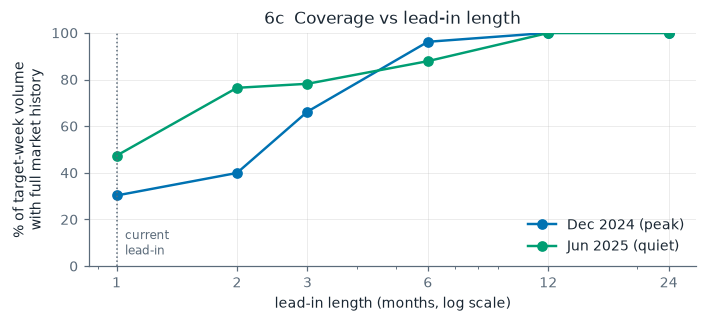

In [20]:
LEADS = [1, 2, 3, 6, 12, 24]
cov_rows = {}
for w, cfg in WINDOWS.items():
    a = age[w]
    start = pd.to_datetime(a["start_date"], utc=True, format="ISO8601")
    t0 = pd.Timestamp(cfg["target_start"], tz="UTC")
    cov = {}
    for L in LEADS:
        lead_start = t0 - pd.DateOffset(months=L)
        known = start >= lead_start          # NaT compares False -> counted as not covered
        cov[L] = 100 * a.loc[known, "v"].sum() / a["v"].sum()
        record_stat(w, f"pct_volume_covered_lead_{L}m", cov[L])
    cov_rows[WIN[w]["label"]] = cov
coverage = pd.DataFrame(cov_rows)
coverage.index.name = "lead-in (months)"

fig, ax = plt.subplots(figsize=(6.5, 3.0))
for w in WIN:
    lab = WIN[w]["label"]
    ax.plot(coverage.index, coverage[lab], marker="o", color=WIN[w]["color"], lw=1.6, label=lab)
ax.axvline(1, color=C_MUTED, ls=":", lw=1)
ax.text(1.05, 5, "current\nlead-in", color=C_MUTED, fontsize=8)
ax.set_xscale("log")
ax.set_xticks(LEADS, [str(L) for L in LEADS])
ax.set(ylim=(0, 100), xlabel="lead-in length (months, log scale)",
       ylabel="% of target-week volume\nwith full market history", title="6c  Coverage vs lead-in length")
ax.legend(frameon=False, loc="lower right")
save_fig(fig, "06c_leadin_coverage")
coverage.round(1)

**อ่านผล:**

- lead-in ปัจจุบัน (1 เดือน) ครอบคลุม volume ที่รู้ประวัติครบแค่ **30% (ธ.ค.) / 47% (มิ.ย.)**
- ขยายเป็น **3 เดือน → 66% / 78%** · ขยายเป็น **6 เดือน → 96% / 88%** · 12 เดือน → ~100%
- กราฟช่วงพีคกระโดดระหว่าง 2→3 เดือน และ 3→6 เดือน เพราะตลาดแชมป์กีฬาเปิดช่วง ส.ค.–ต.ค.
- **ข้อเสนอให้ A:** ขยาย lead-in เป็น **6 เดือน** สำหรับหน้าต่าง ธ.ค. (ครอบคลุม 96%) ต้นทุนคือข้อมูลดิบเพิ่ม ~5 เดือน × ~1 GB
  ถ้าเวลา/พื้นที่ไม่พอ ใช้ 3 เดือนเป็นขั้นต่ำ แล้ว**รายงาน % ที่ถูกติดธงแยกตามกลุ่ม "รู้ประวัติครบ" vs "ไม่ครบ"** เพื่อดูว่าขอบหน้าต่างทำให้ผลเพี้ยนแค่ไหน
- หมายเหตุ: closure ใช้แค่ position ของกระเป๋าใน**ตลาดนั้น** ดังนั้นแค่ตลาดที่เปิดก่อน lead-in เท่านั้นที่ได้รับผล ตลาดที่เปิดในช่วงข้อมูลแล้วปลอดภัย

## 7. สรุปข้อค้นพบ

**อ่านแบบนี้:** แต่ละแถวคือลักษณะที่ต่างกันชัดระหว่างช่วงพีค (wash ~60%) กับช่วงเงียบ (< 5%)
ยิ่งอัตราส่วนสูง ยิ่งน่าจะเป็นร่องรอยของ wash

| # | ลักษณะ | ธ.ค. 2024 (พีค) | มิ.ย. 2025 (เงียบ) | ความหมาย |
|---|---|---|---|---|
| 1 | USDC ต่อหุ้นเฉลี่ย | 0.26 | 0.43 | share volume พองด้วยหุ้นราคาถูก |
| 3b | % volume จากกระเป๋าที่ top-partner share ≥ 0.8 | **19.5%** | 1.5% | เทรดวนกับคู่เดียว |
| 3.3 | % volume จากกระเป๋าที่ top-2 share ≥ 0.9 | **38.2%** | 2.7% | โซ่/วงสองคู่ (ต่าง ~14 เท่า) |
| 4 | % volume หมวด Sports | **57%** | 16% | volume ที่หายไปเมื่อ wash หยุด คือกีฬา |
| 5a | % volume ที่ราคา < 0.02 | **62.6%** | 25.2% | wash ชอบตลาดโอกาสน้อย |
| 5c | เทรดขนาด 96 หุ้นพอดี | **72,855** | 463 | บอทกลุ่มใหญ่ในตลาดที่ผลแน่นอนแล้ว |

**ข้อค้นพบด้านคุณภาพข้อมูล (ส่ง A):**
- ⚠️ lead-in 1 เดือนครอบคลุม volume ที่รู้ประวัติครบแค่ **30%** ของช่วงพีค → เสนอขยายเป็น **6 เดือน (96%)** หรืออย่างน้อย 3 เดือน (66%)
- สัปดาห์เป้าหมายไม่ใช่สัปดาห์ผิดปกติ แต่ lead-in ของ ธ.ค. มีคืนเลือกตั้งสหรัฐ (532 M หุ้น) ซ้อนอยู่
- ปัญหา "ตลาดไร้ชื่อ 39%" ไม่กระทบหน้าต่างของเรา (ชื่อครบ ~100%) · `market_data` ไม่มีคอลัมน์หมวด → จัดเองด้วยคีย์เวิร์ด

**ข้อค้นพบด้านอัลกอริทึม (ส่ง B):**
- ⚠️ ตลาด Trump-inauguration **เปิดใน lead-in** (มีประวัติครบ) → การถูกติดธง 89% **ไม่ได้มาจากขอบหน้าต่าง** ต้องตรวจด้วย Algorithm 2
- กระเป๋าใน band top-partner ≈ 0.5 (7,036 ใบ) และกระเป๋าที่เทรด 96 หุ้น = **ชุด spot check** ที่ผลของ B ควรติดธง
- top-partner share, top-2 share และราคาเฉลี่ยของกระเป๋าเป็นฟีเจอร์ที่ดีสำหรับ Isolation Forest

**ข้อจำกัดของ EDA นี้:**
- ดูแค่สองสัปดาห์ (ไม่ใช่ทั้งช่วง) — รอบสอง (10 ต.ค.) จะทำบนช่วงเต็มที่ A ขยาย และเทียบกระเป๋า "ถูกติดธง vs ไม่ถูก" โดยตรง
- เป็นการเปรียบเทียบระดับช่วงเวลา ยังไม่ได้ระบุว่า**เทรดไหน**เป็น wash — ต้องใช้ผลอัลกอริทึมของ B
- หมวดตลาดเป็นการจัดเองด้วยคีย์เวิร์ด

## บันทึกตัวเลขทั้งหมด

**ทำอะไร:** เขียน `STATS` ทั้งหมดลง `eda_stats.json` — เป็น **แหล่งเดียว** ของตัวเลขที่จะอ้างในสไลด์ รายงาน และ `findings.md`
รัน cell นี้ท้ายสุดเสมอ (หลังทุกหัวข้อ) ไม่งั้นไฟล์จะมีตัวเลขไม่ครบ

In [21]:
(HERE / "eda_stats.json").write_text(json.dumps(STATS, indent=2, default=str))
print(f"saved {sum(len(v) for v in STATS.values())} numbers -> eda_stats.json")
print("figures:", sorted(p.name for p in FIG.glob("*.png")))

saved 78 numbers -> eda_stats.json
figures: ['02_daily_volume.png', '03_degree.png', '04_category_share.png', '05a_price.png', '05b_trade_size.png', '06c_leadin_coverage.png']


ไฟล์ที่ได้จาก notebook นี้:
- `eda_stats.json` — ตัวเลขทั้งหมด (key เดียวกับที่ใช้ใน `record_stat`)
- `figures/*.png` — กราฟทุกรูปสำหรับสไลด์ (ชื่อขึ้นต้นด้วยเลขหัวข้อ)
- `findings.md` — สรุปสั้นสำหรับ A/B (เขียนจากตัวเลขในไฟล์ JSON)